<a href="https://colab.research.google.com/github/eleonoracasalee/ProgettoACC/blob/main/ProgettoACC%40.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
# Importazione librerie
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

# Impostazioni visualizzazione
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


# **PARTE 1: EDA (Exploratory Data Analysis)**

In [6]:
# Caricamento del dataset
df = pd.read_csv('/StudentPerformanceFactors.csv')
display(df.head(10))

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71
6,29,84,Medium,Low,Yes,7,68,Low,Yes,1,Low,Medium,Private,Neutral,2,No,High School,Moderate,Male,67
7,25,78,Low,High,Yes,6,50,Medium,Yes,1,High,High,Public,Negative,2,No,High School,Far,Male,66
8,17,94,Medium,High,No,6,80,High,Yes,0,Medium,Low,Private,Neutral,1,No,College,Near,Male,69
9,23,98,Medium,Medium,Yes,8,71,Medium,Yes,0,High,High,Public,Positive,5,No,High School,Moderate,Male,72


In [19]:
# Elimina le colonne senza nome
df = df.drop(columns=[col for col in df.columns if 'Unnamed' in col])

In [20]:
# Descrizione delle variabili
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [21]:
# Statistiche descrittive — variabili numeriche
print('=== NUMERICHE ===')
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean', 'std']) \
    .highlight_min('mean', color='lightcoral')

=== NUMERICHE ===


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.000000,19.975329,5.990594,1.000000,16.000000,20.000000,24.000000,44.000000
Attendance,6607.000000,79.977448,11.547475,60.000000,70.000000,80.000000,90.000000,100.000000
Sleep_Hours,6607.000000,7.029060,1.468120,4.000000,6.000000,7.000000,8.000000,10.000000
Previous_Scores,6607.000000,75.070531,14.399784,50.000000,63.000000,75.000000,88.000000,100.000000
Tutoring_Sessions,6607.000000,1.493719,1.230570,0.000000,1.000000,1.000000,2.000000,8.000000
Physical_Activity,6607.000000,2.967610,1.031231,0.000000,2.000000,3.000000,4.000000,6.000000
Exam_Score,6607.000000,67.235659,3.890456,55.000000,65.000000,67.000000,69.000000,101.000000


In [22]:
# Statistiche descrittive — variabili categoriche
print('=== CATEGORICHE ===')
df.describe(include=['object', 'string']).T

=== CATEGORICHE ===


,count,unique,top,freq
Parental_Involvement,6607,3,Medium,3362
Access_to_Resources,6607,3,Medium,3319
Extracurricular_Activities,6607,2,Yes,3938
Motivation_Level,6607,3,Medium,3351
Internet_Access,6607,2,Yes,6108
Family_Income,6607,3,Low,2672
Teacher_Quality,6529,3,Medium,3925
School_Type,6607,2,Public,4598
Peer_Influence,6607,3,Positive,2638
Learning_Disabilities,6607,2,No,5912


In [23]:
# Analisi dei valori mancanti
print('=== Valori Mancanti ===')
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage (%)': missing_percentage})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

if not missing_df.empty:
    display(missing_df.style.background_gradient(cmap='Reds'))
else:
    print('Non ci sono valori mancanti nel DataFrame.')

=== Valori Mancanti ===


,Missing Count,Missing Percentage (%)
Parental_Education_Level,90,1.362192
Teacher_Quality,78,1.180566
Distance_from_Home,67,1.014076


In [24]:
# Conteggio dei valori nulli per colonna
print("\nConteggio dei valori NaN/nulli:")
print(df.isnull().sum())


Conteggio dei valori NaN/nulli:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


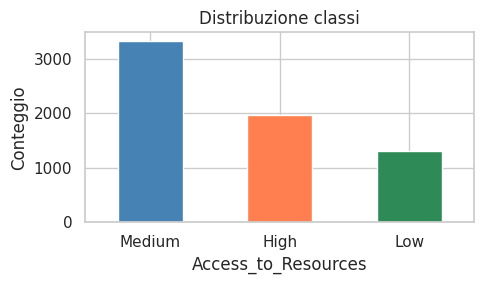

In [25]:
# Distribuzione delle classi
plt.figure(figsize=(5, 3))
df['Access_to_Resources'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
plt.title('Distribuzione classi')
plt.xlabel('Access_to_Resources')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

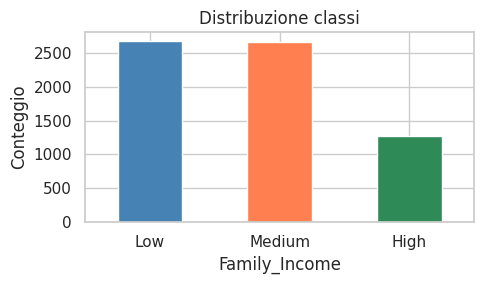

In [26]:
# Distribuzione delle classi
plt.figure(figsize=(5, 3))
df['Family_Income'].value_counts().plot(kind='bar', color=['steelblue', 'coral', 'seagreen'], edgecolor='white')
plt.title('Distribuzione classi')
plt.xlabel('Family_Income')
plt.ylabel('Conteggio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

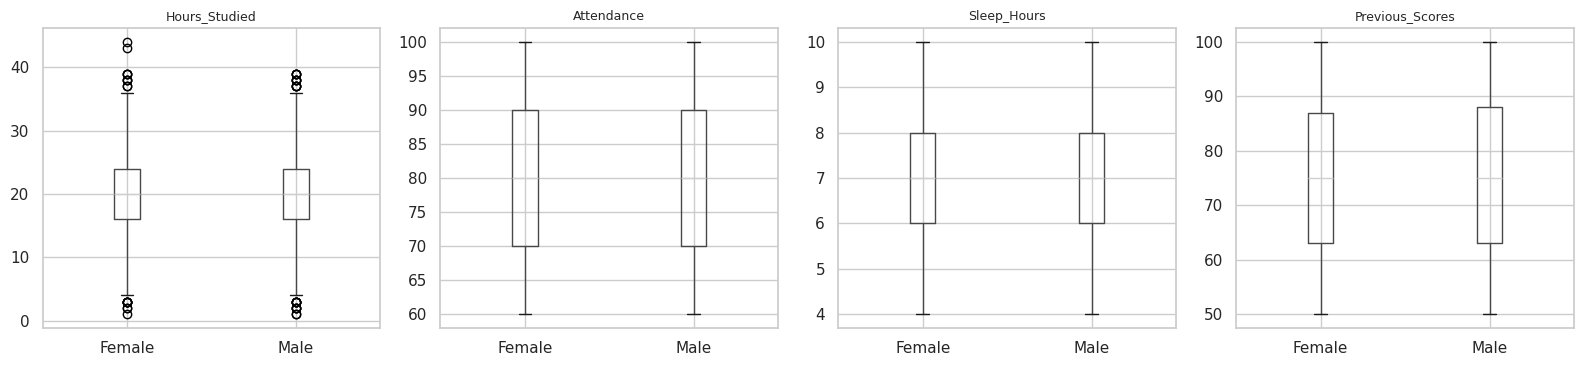

In [27]:
# Boxplot feature per classe
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
selected_features = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores']
for ax, col in zip(axes, selected_features):
    df.boxplot(column=col, by='Gender', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('')
plt.tight_layout()
plt.show()

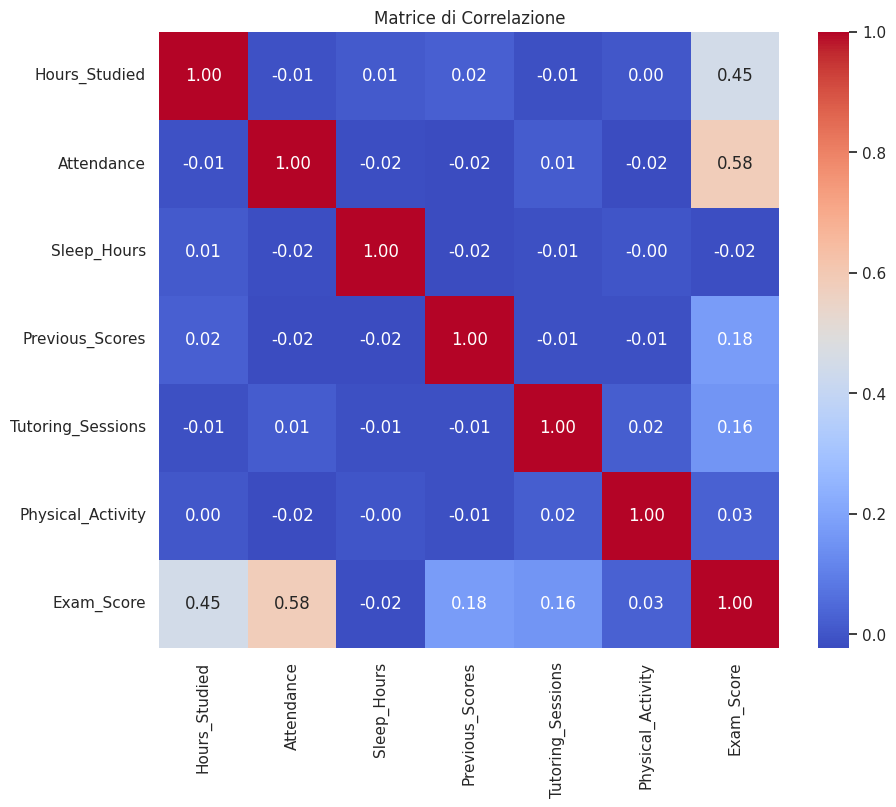

In [28]:
# Calcola la matrice di correlazione (solo per colonne numeriche)
correlation_matrix = df.select_dtypes(include=np.number).corr()

# Visualizza la matrice di correlazione
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matrice di Correlazione')
plt.show()

In [29]:
df[['Attendance', 'Hours_Studied', 'Previous_Scores']].corr()

,Attendance,Hours_Studied,Previous_Scores
Attendance,1.000,-0.010,-0.020
Hours_Studied,-0.010,1.000,0.025
Previous_Scores,-0.020,0.025,1.000


#  **PARTE 2: PREPROCESSING DEI DATI**

In [33]:
# Duplicazione del dataset
df_clean = df.copy()
print(f'Shape iniziale: {df_clean.shape}')

# Preparazione del dataset --> Trasformare le categoriche in numeriche

# 1. Definizione delle mappe per l'Ordinal Encoding (ordine logico)
mappa_3_livelli = {'Low': 0, 'Medium': 1, 'High': 2}
mappa_peer = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
mappa_education = {'High School': 0, 'College': 1, 'Postgraduate': 2}
mappa_distanza = {'Near': 0, 'Moderate': 1, 'Far': 2}

# 2. Applicazione del mapping alle colonne specifiche
df_clean['Access_to_Resources'] = df['Access_to_Resources'].map(mappa_3_livelli)
df_clean['Family_Income'] = df['Family_Income'].map(mappa_3_livelli)
df_clean['Parental_Involvement'] = df['Parental_Involvement'].map(mappa_3_livelli)
df_clean['Motivation_Level'] = df['Motivation_Level'].map(mappa_3_livelli)
df_clean['Teacher_Quality'] = df['Teacher_Quality'].map(mappa_3_livelli)
df_clean['Peer_Influence'] = df['Peer_Influence'].map(mappa_peer)
df_clean['Parental_Education_Level'] = df['Parental_Education_Level'].map(mappa_education)
df_clean['Distance_from_Home'] = df['Distance_from_Home'].map(mappa_distanza)

# 3. Gestione dei valori mancanti (NaN) --> riempiamo i vuoti con la mediana
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

# 4. One-Hot Encoding per le variabili senza ordine (0 o 1)
df_clean = pd.get_dummies(df_clean, columns=['Gender', 'School_Type', 'Internet_Access',
                                 'Extracurricular_Activities', 'Learning_Disabilities'],
                    drop_first=True, dtype=int)

# Salvataggio del file pulito per la fase di addestramento
df_clean.to_csv('StudentPerformance_Cleaned.csv', index=False)

print("Preprocessing completato. Righe nulle rimaste:", df_clean.isnull().sum().sum())
print(df_clean.head())

Shape iniziale: (6607, 20)
Preprocessing completato. Righe nulle rimaste: 0
   Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  \
0             23          84                     0                    2   
1             19          64                     0                    1   
2             24          98                     1                    1   
3             29          89                     0                    1   
4             19          92                     1                    1   

   Sleep_Hours  Previous_Scores  Motivation_Level  Tutoring_Sessions  \
0            7               73                 0                  0   
1            8               59                 0                  2   
2            7               91                 1                  2   
3            8               98                 1                  1   
4            6               65                 1                  3   

   Family_Income  Teacher_Quality  Peer_

In [36]:
# Riepilogo preprocessing
print('=== RIEPILOGO PREPROCESSING ===')
print(f'  Shape originale  : {df.shape}')
print(f'  Valori mancanti originali : {df.isnull().sum().sum()}')
print(f'  Shape finale     : {df_clean.shape}')
print(f'  Valori mancanti finali  : {df_clean.isnull().sum().sum()}')
print(f'  Tipi colonne     : {dict(df_clean.dtypes.value_counts())}')

df_clean.head()

=== RIEPILOGO PREPROCESSING ===
  Shape originale  : (6607, 20)
  Valori mancanti originali : 235
  Shape finale     : (6607, 20)
  Valori mancanti finali  : 0
  Tipi colonne     : {dtype('int64'): np.int64(17), dtype('float64'): np.int64(3)}


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Family_Income,Teacher_Quality,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Exam_Score,Gender_Male,School_Type_Public,Internet_Access_Yes,Extracurricular_Activities_Yes,Learning_Disabilities_Yes
0,23,84,0,2,7,73,0,0,0,1.000,2,3,0.000,0.000,67,1,1,1,0,0
1,19,64,0,1,8,59,0,2,1,1.000,0,4,1.000,1.000,61,0,1,1,0,0
2,24,98,1,1,7,91,1,2,1,1.000,1,4,2.000,0.000,74,1,1,1,1,0
3,29,89,0,1,8,98,1,1,1,1.000,0,4,0.000,1.000,71,1,1,1,1,0
4,19,92,1,1,6,65,1,3,1,2.000,1,4,1.000,0.000,70,0,1,1,1,0


# **PARTE 3: ADDESTRAMENTO DEI MODELLI**

In [59]:
# Importazione librerie
from sklearn.model_selection import train_test_split

# Separazione tra variabili indipendenti e target
X = df_clean.drop('Exam_Score', axis=1)
y = df_clean['Exam_Score']

# Suddivisione del dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'Train: {X_train.shape[0]} campioni')
print(f'Test:  {X_test.shape[0]} campioni')

Train: 5285 campioni
Test:  1322 campioni


In [60]:
# Importazione librerie
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Pipeline per Regressione Lineare
pipeline_lr = Pipeline(steps=[
    ('regressor', LinearRegression())
])

# Pipeline per Random Forest
pipeline_rf = Pipeline(steps=[
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Allenamento dei modelli
for name, pipe in [('Linear Regression', pipeline_lr), ('Random Forest', pipeline_rf)]:
    pipe.fit(X_train, y_train)
    score = pipe.score(X_test, y_test)
    print(f"{name} - R^2 Score: {score:.4f}")

Linear Regression - R^2 Score: 0.7709
Random Forest - R^2 Score: 0.6654


# **PARTE 4: VALUTAZIONE DEI RISULTATI**

In [47]:
# Importazione librerie
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Previsioni
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

def valuta_modello(y_true, y_pred, nome):
    print(f"--- Valutazione {nome} ---")
    print(f"R² Score: {r2_score(y_true, y_pred):.4f}")
    print(f"MAE: {mean_absolute_error(y_true, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_true, y_pred)):.4f}")
    print("\n")

valuta_modello(y_test, y_pred_lr, "Regressione Lineare")
valuta_modello(y_test, y_pred_rf, "Random Forest")

--- Valutazione Regressione Lineare ---
R² Score: 0.7709
MAE: 0.4432
RMSE: 1.7996


--- Valutazione Random Forest ---
R² Score: 0.6654
MAE: 1.0837
RMSE: 2.1748




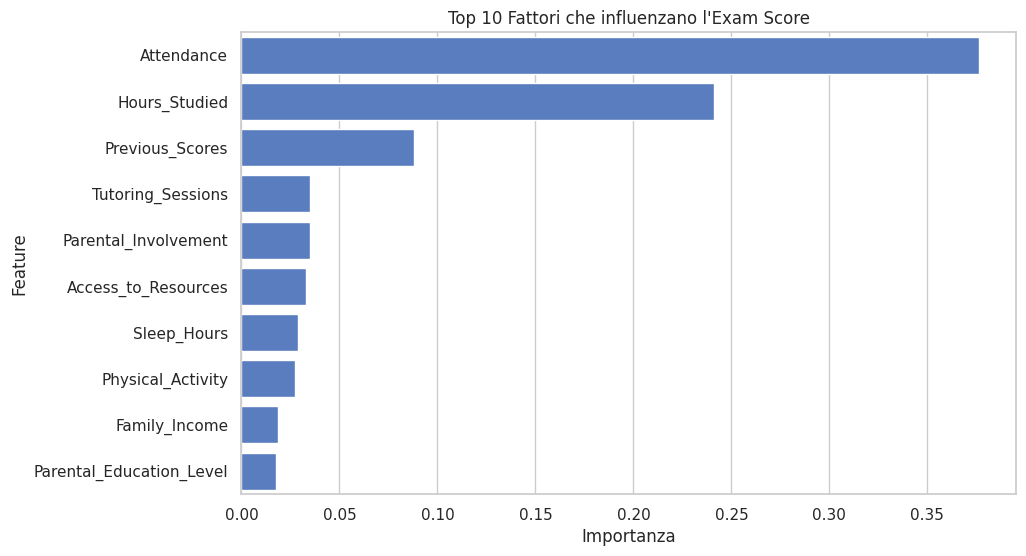

In [ ]:
# Feature Importance
# Estraiamo l'importanza delle variabili dal modello Random Forest
# Quali fattori influenzano di più il voto finale?
importanze = pipeline_rf.named_steps['regressor'].feature_importances_
nomi_colonne = X_train.columns

df_importanze = pd.DataFrame({'Feature': nomi_colonne, 'Importanza': importanze})
df_importanze = df_importanze.sort_values(by='Importanza', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importanza', y='Feature', data=df_importanze)
plt.title("Top 10 Fattori che influenzano l'Exam Score")
plt.show()


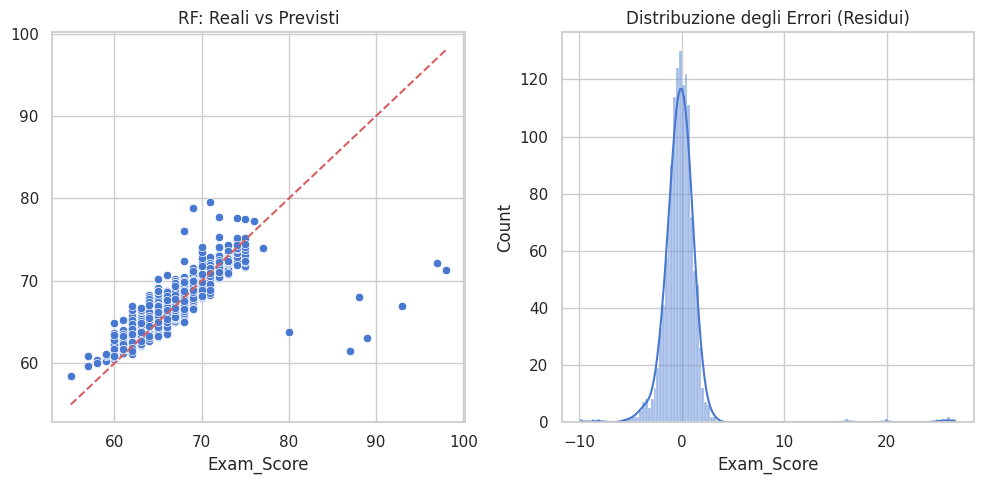

In [52]:
# Impostazione dei grafici
plt.figure(figsize=(10, 5))

# Grafico per Random Forest
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_rf)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.title("RF: Reali vs Previsti")

# Grafico dei Residui
plt.subplot(1, 2, 2)
residui = y_test - y_pred_rf
sns.histplot(residui, kde=True)
plt.title("Distribuzione degli Errori (Residui)")

plt.tight_layout()
plt.show()

In [58]:
#Cross Validation
# Il modello ha realmente imparato bene o i risultati sono solo un caso?
from sklearn.model_selection import cross_val_score

punteggi = cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')
print(f"R² medio su 5 test: {punteggi.mean():.4f} (+/- {punteggi.std() * 2:.4f})")


R² medio su 5 test: 0.6390 (+/- 0.1168)


# **PARTE 5: CONFRONTO TRA I MODELLI**

Tabella comparativa dei modelli:
          Modello  Test R²  CV R² Mean  CV R² Std
Linear Regression    0.771       0.726      0.069
    Random Forest    0.665       0.639      0.058


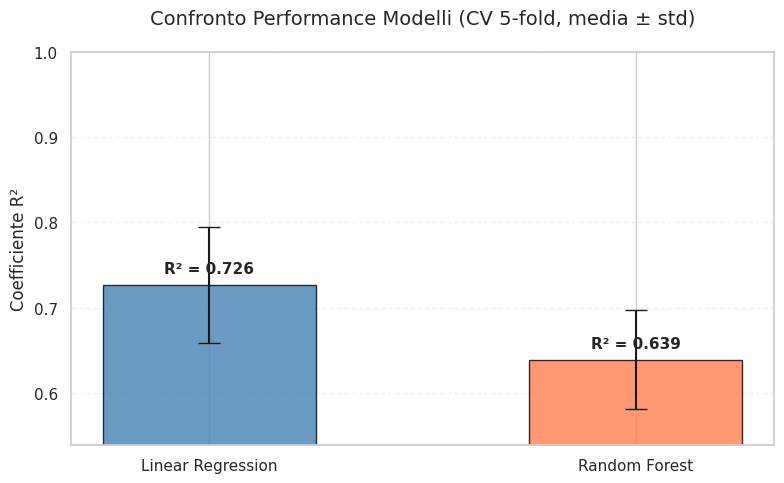

In [56]:
# Calcola l'accuratezza sul test set (R^2 Score)
r2_lr = pipeline_lr.score(X_test, y_test)
r2_rf = pipeline_rf.score(X_test, y_test)

# Cross-Validation per entrambi i modelli
cv_lr = cross_val_score(pipeline_lr, X, y, cv=5, scoring='r2')
cv_rf = cross_val_score(pipeline_rf, X, y, cv=5, scoring='r2')

#  DataFrame riassuntivo
risultati = pd.DataFrame({
    'Modello':       ['Linear Regression', 'Random Forest'],
    'Test R²':       [r2_lr, r2_rf],
    'CV R² Mean':    [cv_lr.mean(), cv_rf.mean()],
    'CV R² Std':     [cv_lr.std(), cv_rf.std()]
}).round(3)

print("Tabella comparativa dei modelli:")
print(risultati.to_string(index=False))

#  Grafico di confronto
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)

# Medie e Deviazioni Standard della Cross-Validation
means = [cv_lr.mean(), cv_rf.mean()]
stds = [cv_lr.std(), cv_rf.std()]

bars = ax.bar(x, means, yerr=stds,
              color=['#4682B4', '#FF7F50'], # SteelBlue e Coral
              width=0.5, capsize=8, edgecolor='black', alpha=0.8)


ax.set_xticks(x)
ax.set_xticklabels(['Linear Regression', 'Random Forest'], fontsize=11)
ax.set_ylabel('Coefficiente R²', fontsize=12)
ax.set_title('Confronto Performance Modelli (CV 5-fold, media ± std)', fontsize=14, pad=20)

# Impostiamo il limite Y in base ai dati (solitamente tra 0 e 1 per R2)
min_y = min(means) - 0.1 if min(means) > 0.1 else 0
ax.set_ylim(min_y, 1.0)

# Aggiunta dei valori numerici sopra le barre
for bar, val in zip(bars, means):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
            f'R² = {val:.3f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()